In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

In [6]:
df = pd.read_csv(r'C:\Users\Vinay Kumar\Downloads\edunet voict\seasonal_agriculture_performance_dataset.csv')

In [8]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [9]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
df.shape

(4000, 28)

In [12]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [13]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [14]:
df.isnull().values.any()

np.True_

In [15]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [18]:
total_rows = len(df)

In [19]:
missing_percent = (df.isnull().sum() / total_rows) * 100

In [20]:
print(missing_percent)

Farm_ID                          0.0
State                            0.0
District                         0.0
Crop                             0.0
Season                           0.0
Farm_Area_Hectares               0.0
Rainfall_mm                      1.2
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
Soil_pH                          0.0
Soil_Moisture_pct                1.0
Nitrogen_kg_ha                   0.0
Phosphorus_kg_ha                 0.0
Potassium_kg_ha                  0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Yield_Tonnes_Ha                  0.8
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

In [21]:
print(missing_percent[missing_percent > 0])

Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


In [26]:
df = df.fillna(0)
print(df.isnull().sum())

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64


In [27]:
df['Season'] = df['Season'].str.strip().str.lower()

In [28]:
print("Unique Seasons:", df['Season'].unique())

Unique Seasons: ['kharif' 'rabi' 'zaid']


#  Exploratory Data Analysis (EDA)

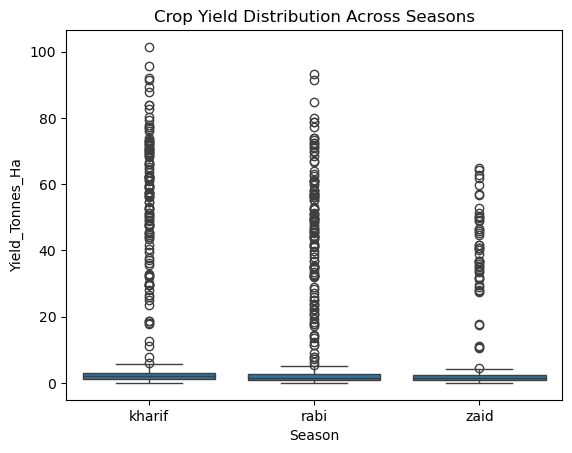

In [30]:
sns.boxplot(x="Season", y="Yield_Tonnes_Ha", data=df)
plt.title("Crop Yield Distribution Across Seasons")
plt.show()

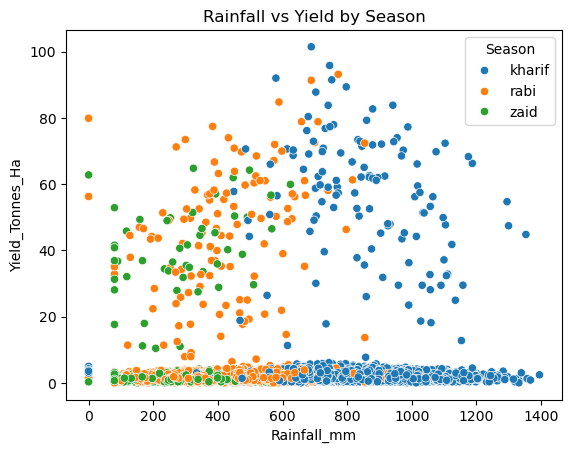

In [32]:
sns.scatterplot(x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", data=df)
plt.title("Rainfall vs Yield by Season")
plt.show()

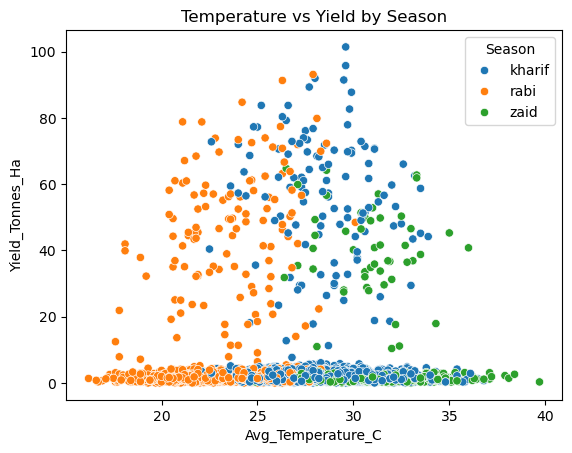

In [34]:
sns.scatterplot(x="Avg_Temperature_C", y="Yield_Tonnes_Ha", hue="Season", data=df)
plt.title("Temperature vs Yield by Season")
plt.show()

In [38]:
# Compare Performance Across Different Periods

          Yield_Tonnes_Ha     Profit_INR
District                                
Rajkot           6.015810  119463.276808
Nalgonda         5.788602  131125.836145
Ludhiana         5.779508   87590.831382
Warangal         5.482773  166449.962085
Guntur           5.458974  116411.417949


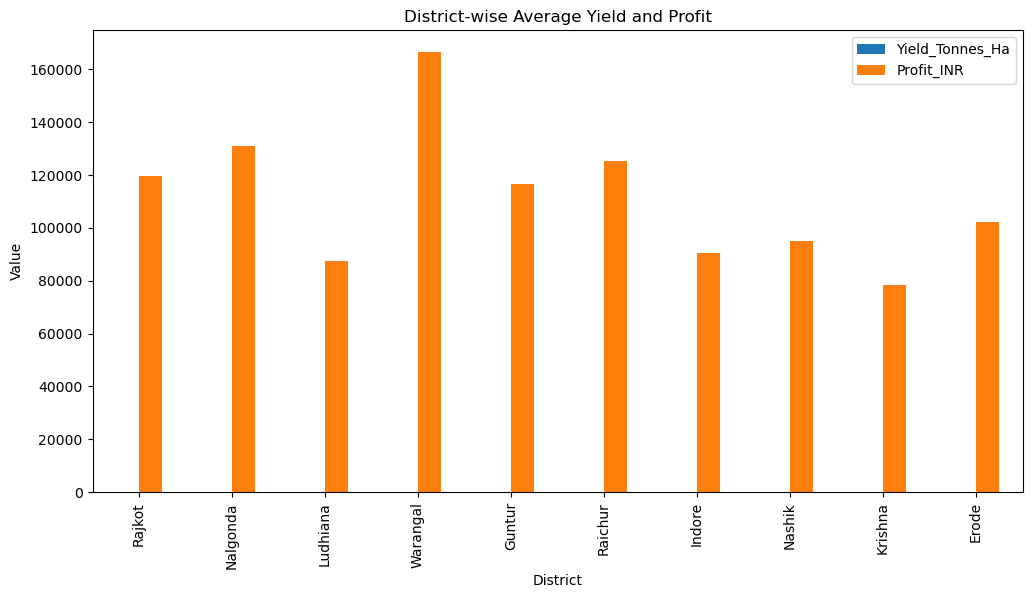

In [39]:
# Compare yield and profit by district
district_summary = df.groupby("District")[["Yield_Tonnes_Ha","Profit_INR"]].mean().sort_values("Yield_Tonnes_Ha", ascending=False)
print(district_summary.head())

# Visualization
district_summary.plot(kind="bar", figsize=(12,6))
plt.title("District-wise Average Yield and Profit")
plt.ylabel("Value")
plt.show()


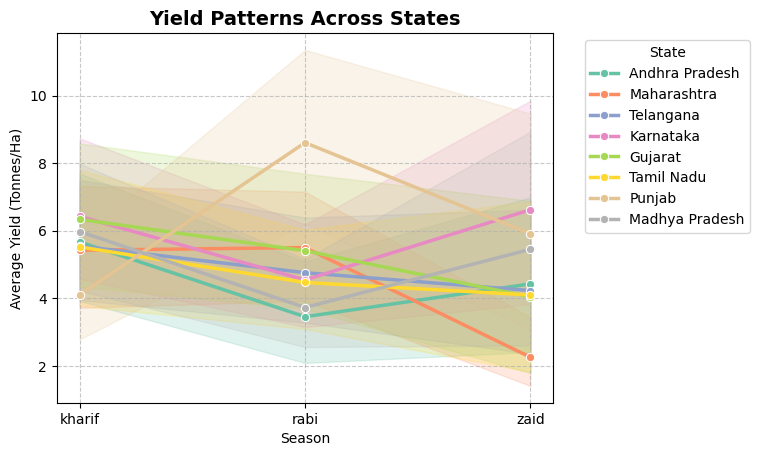

In [59]:
sns.lineplot(
    x="Season", 
    y="Yield_Tonnes_Ha", 
    hue="State", 
    data=df, 
    estimator=np.mean, 
    marker="o", 
    linewidth=2.5, 
    palette="Set2"
)
plt.title("Yield Patterns Across States", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


In [58]:
season_avg = df.groupby("Season")["Yield_Tonnes_Ha"].mean()
district_avg = df.groupby(["District","Season"])["Yield_Tonnes_Ha"].mean().unstack()
anomalies = district_avg[(district_avg["kharif"] < season_avg["kharif"]) & (district_avg["rabi"] > season_avg["rabi"])]
print("Anomalous Districts:\n", anomalies)


Anomalous Districts:
 Season      kharif      rabi      zaid
District                              
Raichur   4.050449  6.645646  3.287705
Warangal  5.269356  5.645952  5.784615


In [50]:
df["ROI"] = df["Profit_INR"] / df["Total_Cost_INR"]
roi_summary = df.groupby("Season")["ROI"].mean()
print(roi_summary)


Season
kharif    0.354505
rabi      0.175977
zaid     -0.024671
Name: ROI, dtype: float64


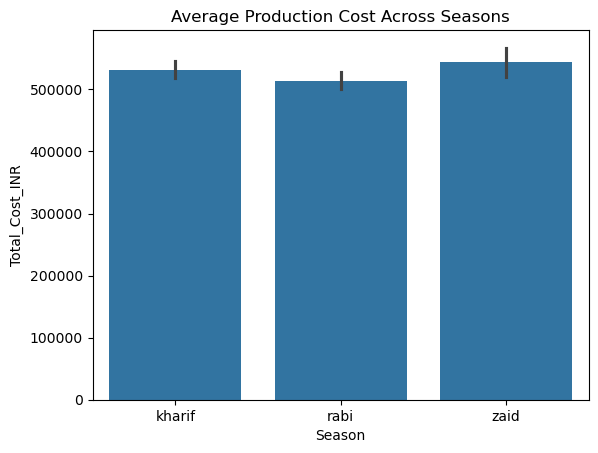

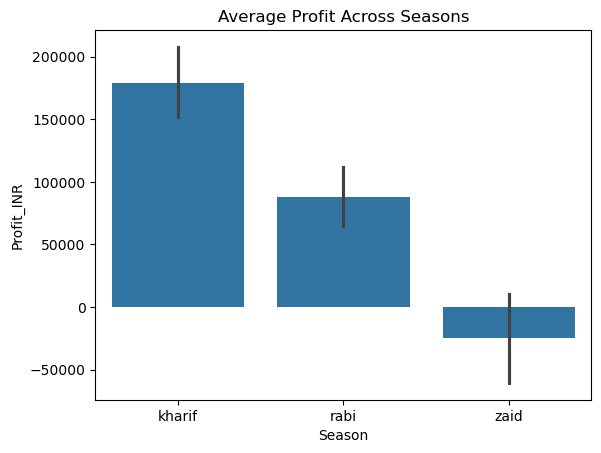

In [51]:
sns.barplot(x="Season", y="Total_Cost_INR", data=df, estimator=np.mean)
plt.title("Average Production Cost Across Seasons")
plt.show()

sns.barplot(x="Season", y="Profit_INR", data=df, estimator=np.mean)
plt.title("Average Profit Across Seasons")
plt.show()


In [40]:
# Understand Changing Environmental Conditions

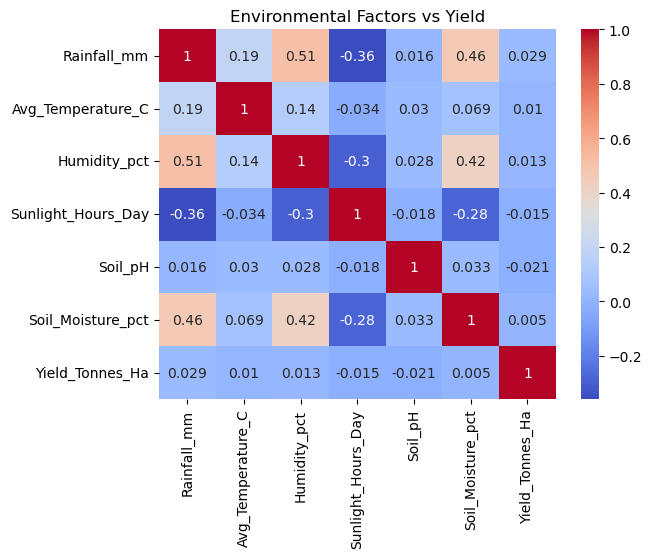

In [41]:
# Correlation between environmental factors and yield
env_factors = ["Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day","Soil_pH","Soil_Moisture_pct"]
sns.heatmap(df[env_factors + ["Yield_Tonnes_Ha"]].corr(), annot=True, cmap="coolwarm")
plt.title("Environmental Factors vs Yield")
plt.show()


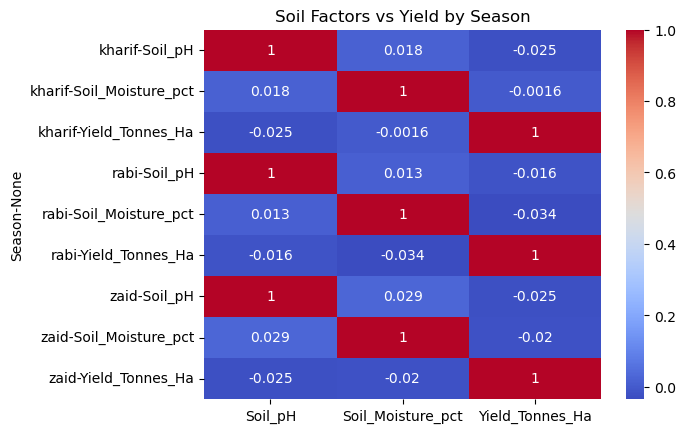

In [56]:
#Does soil pH or moisture have a stronger impact on yield in specific seasons?
sns.heatmap(df.groupby("Season")[["Soil_pH","Soil_Moisture_pct","Yield_Tonnes_Ha"]].corr(), annot=True, cmap="coolwarm")
plt.title("Soil Factors vs Yield by Season")
plt.show()


In [42]:
# Examine Differences in Resource Usage

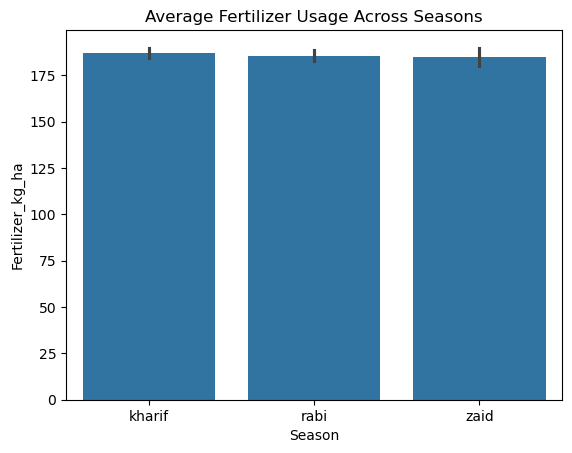

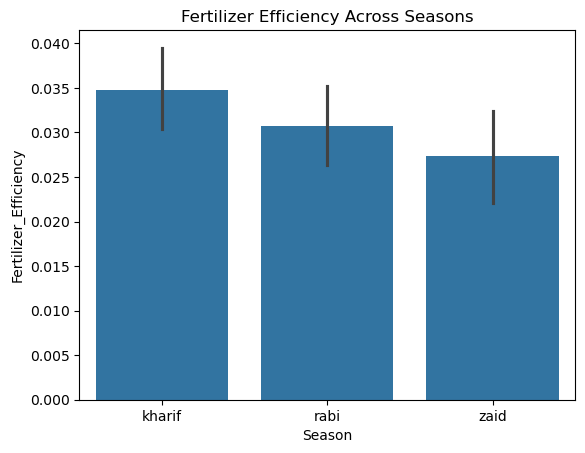

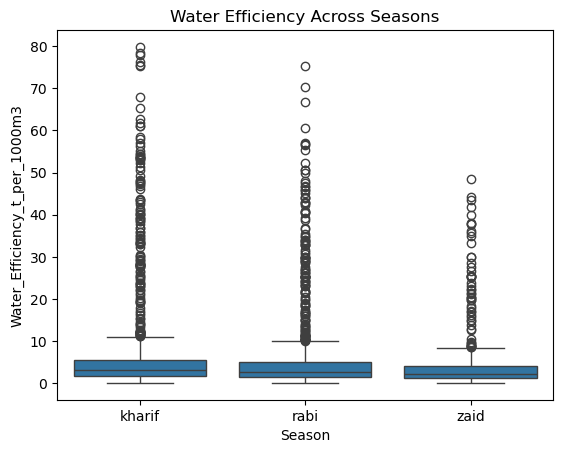

In [53]:
sns.barplot(x="Season", y="Fertilizer_kg_ha", data=df, estimator=np.mean)
plt.title("Average Fertilizer Usage Across Seasons")
plt.show()

df["Fertilizer_Efficiency"] = df["Yield_Tonnes_Ha"] / df["Fertilizer_kg_ha"]
sns.barplot(x="Season", y="Fertilizer_Efficiency", data=df, estimator=np.mean)
plt.title("Fertilizer Efficiency Across Seasons")
plt.show()

sns.boxplot(x="Season", y="Water_Efficiency_t_per_1000m3", data=df)
plt.title("Water Efficiency Across Seasons")
plt.show()


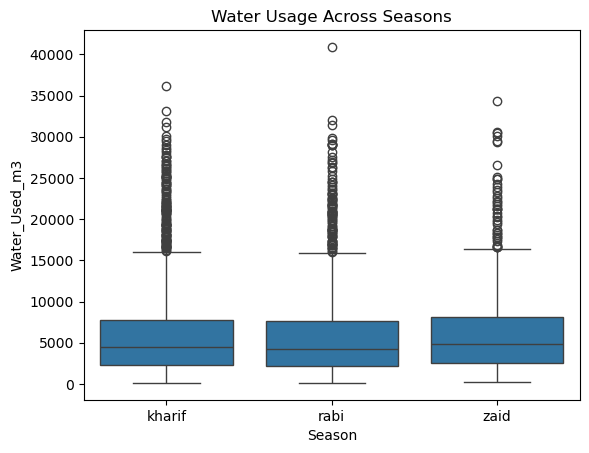

In [52]:
sns.boxplot(x="Season", y="Water_Used_m3", data=df)
plt.title("Water Usage Across Seasons")
plt.show()


In [44]:
# Identify Areas Requiring Further Investigation

In [45]:
# Detect anomalies: unusually high yield despite low rainfall
anomalies = df[(df["Rainfall_mm"] < df["Rainfall_mm"].mean()/2) & (df["Yield_Tonnes_Ha"] > df["Yield_Tonnes_Ha"].mean())]
print("Anomalies Detected:\n", anomalies[["District","Season","Rainfall_mm","Yield_Tonnes_Ha"]])


Anomalies Detected:
       District Season  Rainfall_mm  Yield_Tonnes_Ha
47    Ludhiana   zaid         90.0            36.69
253   Ludhiana   zaid          0.0            62.76
306   Nalgonda   zaid        158.7            49.31
324   Ludhiana   zaid         80.0            41.51
342     Rajkot   rabi         80.0            32.80
486     Guntur   zaid        252.9            49.80
549   Ludhiana   zaid        283.1            10.97
655     Indore   rabi        274.1            12.45
701   Ludhiana   rabi        248.7            49.04
792   Ludhiana   zaid        172.4            17.92
796     Guntur   zaid        207.6            10.40
814   Warangal   zaid        117.1            45.79
829   Nalgonda   rabi        290.4            42.05
860    Raichur   rabi        199.0            22.34
930   Ludhiana   rabi        287.9            34.27
937     Rajkot   zaid         80.0            28.05
1089  Ludhiana   rabi        195.2            44.19
1373    Indore   zaid        234.6         

In [47]:
# Summarize key insights
season_summary = df.groupby("Season")[["Yield_Tonnes_Ha","Profit_INR","Water_Efficiency_t_per_1000m3"]].mean()
print(season_summary)

best_season_yield = season_summary["Yield_Tonnes_Ha"].idxmax()
best_season_profit = season_summary["Profit_INR"].idxmax()

print(f" Best season for yield: {best_season_yield}")
print(f" Best season for profit: {best_season_profit}")
print("Recommendation: Align crop planning and resource allocation with these seasonal strengths.")


        Yield_Tonnes_Ha     Profit_INR  Water_Efficiency_t_per_1000m3
Season                                                               
kharif         5.621765  178914.647555                       5.891834
rabi           5.018045   87689.470191                       5.186122
zaid           4.626667  -24804.824916                       4.413239
 Best season for yield: kharif
 Best season for profit: kharif
Recommendation: Align crop planning and resource allocation with these seasonal strengths.


# Recommendations

1.Season-Specific Crop Planning

Focus on high-yield crops during the season identified as most productive (e.g., Rabi for cereals, Kharif for rice).

Introduce drought-resistant or short-duration crops in low-yield seasons like summer.

2.Resource Optimization

Adjust fertilizer and pesticide usage based on soil moisture and nutrient levels to avoid overuse.

Improve irrigation efficiency in water-scarce seasons by adopting drip or sprinkler systems.

3.Climate Adaptation Strategies

Monitor rainfall and temperature trends to anticipate seasonal risks.

Promote crop diversification to reduce dependency on a single crop vulnerable to climate variations.

4.District-Level Targeting

Prioritize resource allocation to districts with consistently lower yields.

Share best practices from high-performing districts to improve weaker regions.

5.Economic Planning

Align sowing and harvesting schedules with market demand to maximize profitability.

Encourage collective bargaining or farmer cooperatives to stabilize market prices.

6.Evidence-Based Decision Making

Use correlation insights (e.g., rainfall vs yield, soil moisture vs yield) to guide agricultural policies.

Support government and local agencies in designing seasonal subsidy programs for inputs like seeds and fertilizers.

7.Further Investigation

Explore anomalies (e.g., high yield despite low rainfall) to identify innovative practices or hidden factors.

Conduct deeper analysis on soil health and pest risk to refine recommendations.

# Analytical Questions

1.How does crop yield vary between Kharif, Rabi, and Summer seasons?

2.Which season consistently shows the highest profitability across districts?

3.What recurring rainfall and temperature trends can be observed across seasons?

4.Do soil moisture and sunlight hours follow predictable seasonal cycles?

5.How do fertilizer and pesticide usage differ between seasons?

6.Are there shifts in irrigation methods depending on the season?

7.Which districts show the largest differences in yield between Kharif and Rabi?

8.Are certain crops more resilient across multiple seasons compared to others?

9.Is water usage significantly higher in one season compared to others?

10.How does fertilizer efficiency (yield per kg of fertilizer) vary seasonally?


